<a href="https://www.kaggle.com/code/nahuelfuentes/vaca-muerta-oil-gas-production-analysis?scriptVersionId=319427010" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Vaca muerta: Oil & Gas Production Analysis
---
**Author:** Nahuel Ignacio Fuentes
**Data Source:** datos.energia.gob.ar  
**Period:** 2006-2026  
**Goal:** Analyze production trends across Neuquén basin wells

## Why This Dataset?

This is a **real-world dataset** provided by Argentina's Secretary of Energy 
(datos.energia.gob.ar) that records monthly production reports submitted by 
oil and gas companies operating across the country.

## Useful fact about the dataset:

- Mandatory reporting : Companies are legally required to submit monthly production data for every active well
- Well-level granularity : Each row represents one well's monthly production, giving detailed insight into field performance
- Long time series : Data spans from 2006 to present, capturing major industry shifts like the Vaca Muerta shale boom


## What we can learn from it:
- Where are the mayority of deposits?
- Which companies are exploiting each resource?
- How much oil, gas and water are produced in each deposit?
- Which is deposit has given the most product?
- Which deposit are declining in resources?

For this we use multiple interactive views for filtering between companies, deposits and resources.

In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


# For keeping the interactive display on commited version
import plotly.io as pio
pio.renderers.default = 'iframe'

Import dataset using pandas

In [2]:
# Dataset provided by datos.energia.gob.ar
url = "http://datos.energia.gob.ar/dataset/c846e79c-026c-4040-897f-1ad3543b407c/resource/b5b58cdc-9e07-41f9-b392-fb9ec68b0725/download/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"

# Load dataframe
df = pd.read_csv(url)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400759 entries, 0 to 400758
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               400759 non-null  object 
 1   anio                    400759 non-null  int64  
 2   mes                     400759 non-null  int64  
 3   idpozo                  400759 non-null  int64  
 4   prod_pet                400759 non-null  float64
 5   prod_gas                400759 non-null  float64
 6   prod_agua               400759 non-null  float64
 7   iny_agua                400759 non-null  float64
 8   iny_gas                 400759 non-null  float64
 9   iny_co2                 400759 non-null  float64
 10  iny_otro                400759 non-null  float64
 11  tef                     400759 non-null  float64
 12  vida_util               8468 non-null    float64
 13  tipoextraccion          400158 non-null  object 
 14  tipoestado          

# Filter dataset 

## Row example

In [3]:
print(df.iloc[0])

idempresa                                          YSUR
anio                                               2018
mes                                                   1
idpozo                                           132771
prod_pet                                          7.212
prod_gas                                        510.173
prod_agua                                          0.34
iny_agua                                            0.0
iny_gas                                             0.0
iny_co2                                             0.0
iny_otro                                            0.0
tef                                               30.15
vida_util                                           NaN
tipoextraccion                        Surgencia Natural
tipoestado                          Extracción Efectiva
tipopozo                                       Gasífero
observaciones                                       NaN
fechaingreso                 2018-02-10 08:37:14

## Dropping columns

Rename columns for easy usage in map viewing

In [4]:
df.rename(columns={
    "coordenaday":"lat",
    "coordenadax":"lon"
}, inplace=True)

Only choose those related to the cuenca neuquina and drop columns that we won't be using

In [5]:
df_neuquina = df[df['cuenca'] == 'NEUQUINA']
df_neuquina = df.drop(columns=['iny_agua','iny_gas','iny_otro','iny_co2','tef',
                               'observaciones','rectificado','habilitado','idusuario','sigla','formprod',
                               'idareapermisoconcesion','areapermisoconcesion','sub_tipo_recurso'])

## Handling unique and null values

See if the value 'vida_util' is usable because of null values and if there is more than one type of resource

In [6]:

print('Percentage of rows with null "vida_util" values : ', (df_neuquina['vida_util'].isnull().sum() / df_neuquina.shape[0]) * 100,'%')
print('Possible resource type are :',df_neuquina['tipo_de_recurso'].unique())

Percentage of rows with null "vida_util" values :  97.88700939966414 %
Possible resource type are : ['NO CONVENCIONAL']


It's not usable for the sheer amount of null values in relationship to the number of rows, also we could drop resource type as it's only one possible

In [7]:
df_neuquina = df_neuquina.drop(columns=['vida_util','tipo_de_recurso'])

# Views

## Location based oil well

In [8]:
df_oil_wells = df_neuquina[["idpozo","areayacimiento","lat","lon","prod_pet","prod_gas","prod_agua"]].drop_duplicates(subset="idpozo")

df_oil_wells["hover_pet"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) + "<br>Oil production: " + df_oil_wells["prod_pet"].astype(str)+"m³"
df_oil_wells["hover_gas"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) +"<br>Gas production: " + df_oil_wells["prod_gas"].astype(str)+"Mm³"
df_oil_wells["hover_water"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) +"<br>Water production: " + df_oil_wells["prod_agua"].astype(str)+"m³"

first_year = sorted(df_neuquina['anio'].unique())[0]
last_year = sorted(df_neuquina['anio'].unique())[-1]

In [9]:
fig = go.Figure()

fig.add_trace(
    go.Scattermapbox(
        name='Oil',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=True,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_pet"],
            size=df_oil_wells["prod_pet"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_pet"].max() / (20**2),  # controls scale
            sizemin=3                           # minimum marker size
        ),
        text=df_oil_wells["hover_pet"],
        hoverinfo="text"
    )
)
fig.add_trace(
    go.Scattermapbox(
        name='Gas',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_gas"],
            size=df_oil_wells["prod_gas"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_gas"].max() / (20**2),  # controls scale
            sizemin=2                           # minimum marker size
        ),
        text=df_oil_wells["hover_gas"],
        hoverinfo="text"
    )
)

fig.add_trace(
    go.Scattermapbox(
        name='Water',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_agua"],
            colorscale="Blues",
            cmin=df_oil_wells["prod_agua"].quantile(0.20),
            cmax=df_oil_wells["prod_agua"].quantile(0.95),
            size=df_oil_wells["prod_agua"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_agua"].max() / (20**2),  # controls scale
            sizemin=3                           # minimum marker size
        ),
        text=df_oil_wells["hover_water"],
        hoverinfo="text"
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(label="Oil",
                     method="update",
                     args=[{"visible": [True, False, False]}]),
                dict(label="Gas",
                     method="update",
                     args=[{"visible": [False, True, False]}]),
                dict(label="Water",
                     method="update",
                     args=[{"visible": [False, False, True]}]),
            ],
            direction="right",
            x=0.01,
            y=0.99,
        )
    ],
    margin={"r":0,"t":50,"l":0,"b":20},
    mapbox_style="carto-positron",
    mapbox_zoom=9,
    mapbox_center={"lat": -38.4, "lon": -68.7},
    title=f"Total production from {first_year}-{last_year}"
)

fig.show()

## Deposit size based on production

Filter dataset by adding all the production on each deposit and normalize values

In [10]:
df_deposits = df_neuquina.groupby("areayacimiento").agg(
    prod_pet=("prod_pet","sum"),
    prod_gas=("prod_gas","sum"),
    prod_agua=("prod_agua","sum"),
    lat=("lat","first"),
    lon=("lon","first")
).reset_index()

# For displaying purposes

# We normalize and scale for a better sizing display
df_deposits["prod_pet_norm"] = (df_deposits["prod_pet"] / df_deposits["prod_pet"].max()) * 100  
df_deposits["prod_gas_norm"] = (df_deposits["prod_gas"] / df_deposits["prod_gas"].max()) * 100  
df_deposits["prod_agua_norm"] = (df_deposits["prod_agua"] / df_deposits["prod_agua"].max()) * 100

# Text on hover
df_deposits["hover_pet"] = df_deposits["areayacimiento"] + "<br>Oil production: " + df_deposits["prod_pet"].astype(str)
df_deposits["hover_gas"] = df_deposits["areayacimiento"] + "<br>Gas production: " + df_deposits["prod_gas"].astype(str)
df_deposits["hover_agua"] = df_deposits["areayacimiento"] + "<br>Water production: " + df_deposits["prod_agua"].astype(str)

Generate view using Plotly Scattermapbox with markers based on color and size

In [11]:
fig = go.Figure()

fig.add_trace(
    go.Scattermapbox(
        name='Oil',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=True,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Viridis",
            color=df_deposits["prod_pet"],
            size=df_deposits["prod_pet_norm"],
            sizemode="diameter",                   
            sizemin=3                         
        ),
        text=df_deposits["hover_pet"],
        hoverinfo="text"
    )
)
fig.add_trace(
    go.Scattermapbox(
        name='Gas',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Viridis",
            color=df_deposits["prod_gas"],
            size=df_deposits["prod_gas_norm"],
            sizemode="diameter",                
            sizemin=3                        
        ),
        text=df_deposits["hover_gas"],
        hoverinfo="text"
    )
)

fig.add_trace(
    go.Scattermapbox(
        name='Water',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Blues",
            color=df_deposits["prod_agua"],
            size=df_deposits["prod_agua_norm"],
            sizemode="diameter",                   
            sizemin=3                         
        ),
        text=df_deposits["hover_agua"],
        hoverinfo="text"
    )
)

fig.update_layout(
      updatemenus=[
        dict(
            buttons=[
                dict(label="Oil",
                     method="update",
                     args=[{"visible": [True, False, False]}]),
                dict(label="Gas",
                     method="update",
                     args=[{"visible": [False, True, False]}]),
                dict(label="Water",
                     method="update",
                     args=[{"visible": [False, False, True]}]),
            ],
            direction="right",
            x=0.01,
            y=0.99,
        )
    ],
    margin={"r":0,"t":0,"l":0,"b":0},
    mapbox_style="carto-positron",
    mapbox_zoom=9,
    mapbox_center={"lat": -38.4, "lon": -68.7}
)

fig.show()

## Oil production by company

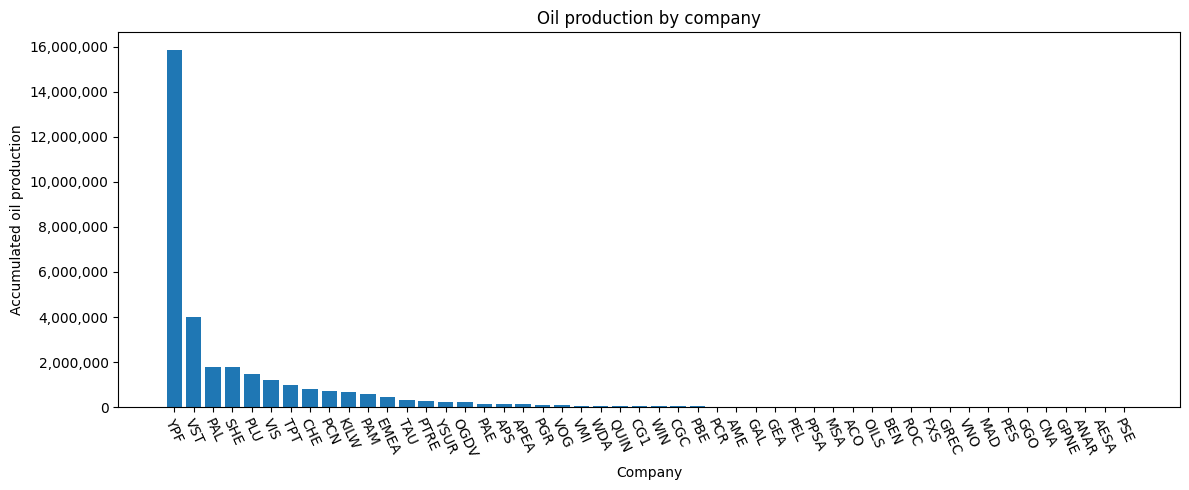

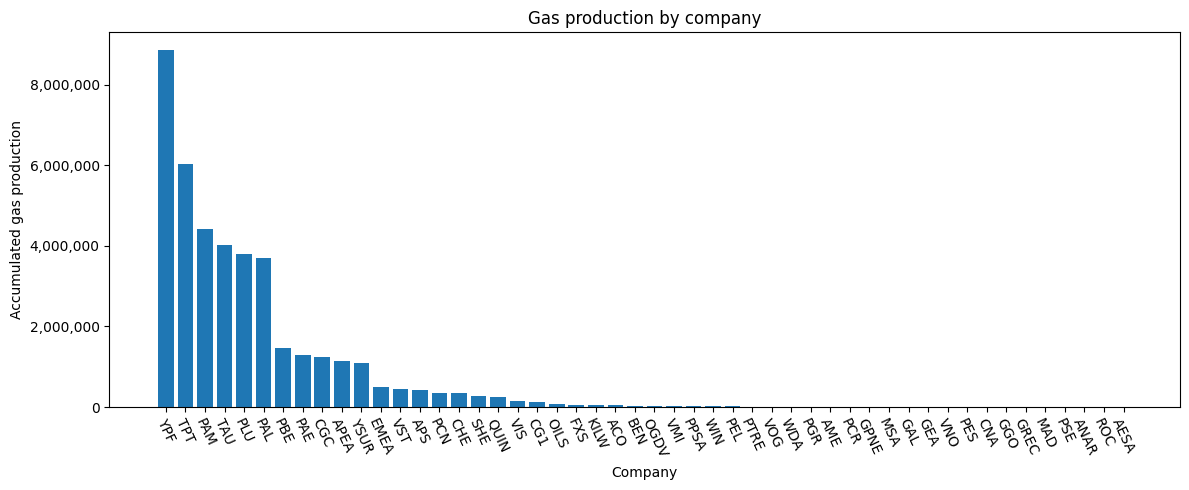

In [12]:
# Accumalted the producted on the table
df_prod_by_company = df_neuquina.groupby(["idempresa","anio"])[list(["prod_pet","prod_gas"])].sum().reset_index()

df_prod_pet_by_company = df_prod_by_company.sort_values(['prod_pet'], ascending=False)
df_prod_gas_by_company = df_prod_by_company.sort_values(['prod_gas'], ascending=False)

# Optional drop company that doesn't produce that resource

df_prod_pet_by_company = df_prod_pet_by_company[df_prod_pet_by_company['prod_pet'] != 0]
df_prod_gas_by_company = df_prod_gas_by_company[df_prod_gas_by_company['prod_gas'] != 0]

# Plot both figures

plt.figure(figsize=(12,5))
plt.bar(df_prod_pet_by_company['idempresa'], df_prod_pet_by_company['prod_pet'])
plt.title("Oil production by company")
plt.xlabel("Company")
plt.xticks(rotation=-65)
plt.ylabel("Accumulated oil production")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.bar(df_prod_gas_by_company['idempresa'], df_prod_gas_by_company['prod_gas'])
plt.title("Gas production by company")
plt.xlabel("Company")
plt.xticks(rotation=-65)
plt.ylabel("Accumulated gas production")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## Filter production type by year

In [13]:
# With plotly
years = sorted(df_prod_by_company['anio'].unique())

fig2 = go.Figure()

# Add traces for each type of production by year
for y in years:
    d = df_prod_by_company[df_prod_by_company["anio"] == y]
    fig2.add_trace(go.Bar(
        x=d.sort_values('prod_pet', ascending=False)['idempresa'],
        y=d.sort_values('prod_pet', ascending=False)['prod_pet'],
        name=f"Petrol {y}", visible=False,
        marker_color = '#2c2c2c'
    ))
    fig2.add_trace(go.Bar(
        x=d.sort_values('prod_gas', ascending=False)['idempresa'],
        y=d.sort_values('prod_gas', ascending=False)['prod_gas'],
        name=f"Gas {y}", visible=False,
        marker_color = '#1f77b4'
    ))

n = len(years)

# Web build one button for each year to choose from
buttons = []
for i, y in enumerate(years):
    for j, (label, offset) in enumerate([("Oil", 0), ("Gas", 1)]):
        vis = [False] * (2 * n)
        vis[2 * i + offset] = True
        yaxis_title = "Production (m³)" if label == "Oil" else "Production (Mm³)"
        buttons.append(
            {"label": f"{label} {y}", "method": "update", "args": [{"visible": vis}, {"yaxis": {"title": yaxis_title}}]}
        )

# Set first trace visible by default
fig2.data[0].visible = True

fig2.update_layout(
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "x": 0.7, "y": 1.2,
        "showactive": True
    }],
    xaxis_title="Company",
    yaxis_title="Production (m³)"
)
fig2.show()

### Widget instead of dash because of kaggle limitations

In [59]:
import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.graph_objects as go

year_dropdown = widgets.Dropdown(
    options=sorted(df_prod_by_company["anio"].unique()),
    description="Year:"
)

product_dropdown = widgets.Dropdown(
    options=[("Petrol", "prod_pet"), ("Gas", "prod_gas")],
    description="Product:"
)

def update_chart(selected_year, selected_product):
    d = df_prod_by_company[df_prod_by_company["anio"] == selected_year]
    d = d.sort_values(selected_product, ascending=False)
    fig = go.Figure(go.Bar(x=d["idempresa"], y=d[selected_product]))
    fig.update_layout(title=f"Vaca Muerta — {selected_product} {selected_year}")
    fig.show()

widgets.interact(update_chart, selected_year=year_dropdown, selected_product=product_dropdown)

interactive(children=(Dropdown(description='Year:', options=(np.int64(2006), np.int64(2007), np.int64(2008), n…

<function __main__.update_chart(selected_year, selected_product)>

### Production of petrol and oil by company through the years

In [15]:
df_prod_through_years = df_neuquina.groupby(['idempresa','anio'])[list(['prod_pet','prod_gas'])].sum().reset_index()

# Select companies and years
companies = df_neuquina['idempresa'].unique()

colors = px.colors.sample_colorscale("Viridis", len(companies))


fig3 = go.Figure()



for c in companies:
    d = df_prod_through_years[df_prod_through_years['idempresa'] == c ].sort_values('anio')
    
    fig3.add_trace(
        go.Scatter(
            y=d['prod_pet'],
            x=d['anio'],
            name=f"{c}",
            marker_color=colors
        )
    )

first_year = df_prod_through_years.sort_values('anio')['anio'].unique()[0]
last_year = df_prod_through_years.sort_values('anio')['anio'].unique()[-1]

fig3.update_layout(
    xaxis_range=[first_year,last_year],
    title="Oil production through the years",
    margin={"r":50,"t":50,"b":50,"l":50},
    yaxis_title = "Production (m³)",
    xaxis_title = "Years"
)

fig3.show()



In [16]:
df_prod_through_years = df_neuquina.groupby(['idempresa','anio'])[list(['prod_pet','prod_gas'])].sum().reset_index()

# Select companies and years
companies = df_neuquina['idempresa'].unique()

colors = px.colors.sample_colorscale("Viridis", len(companies))


fig3 = go.Figure()



for c in companies:
    d = df_prod_through_years[df_prod_through_years['idempresa'] == c ].sort_values('anio')
    
    fig3.add_trace(
        go.Scatter(
            y=d['prod_gas'],
            x=d['anio'],
            name=f"{c}",
            marker_color=colors
        )
    )


fig3.data[0].visible = True

first_year = df_prod_through_years.sort_values('anio')['anio'].unique()[0]
last_year = df_prod_through_years.sort_values('anio')['anio'].unique()[-1]

fig3.update_layout(
    xaxis_range=[first_year,last_year],
    title="Gas production through the years",
    margin={"r":50,"t":50,"b":50,"l":50},
    yaxis_title = "Production (Mm³)",
    xaxis_title = "Year"
)

fig3.show()
    


### See correlations between water production and oil & gas production from deposit

In [17]:
# Separte deposits

df_prod_by_deposit = df_neuquina.groupby(['areayacimiento','anio'])[list(['prod_pet','prod_gas','prod_agua'])].sum().reset_index()

df_deposit_most_water = df_prod_by_deposit.groupby(['areayacimiento'])['prod_agua'].sum().reset_index()
deposits = df_deposit_most_water.sort_values('prod_agua', ascending= False)['areayacimiento'].unique()

deposits_buttons = []
for i, c in enumerate(deposits):
    vis = [False] * (len(deposits) * 3)
    vis[i*3] = True      # gas
    vis[i*3 + 1] = True  # oil
    vis[i*3 + 2] = True  # water
    deposits_buttons.append({
        "label":str(c),
        "method":"update",
        "args":[{"visible":vis}]
    })

fig4 = go.Figure()

for dep in deposits:
    d = df_prod_by_deposit[df_prod_by_deposit['areayacimiento'] == dep].sort_values('anio')
    
    fig4.add_trace(
        go.Scatter(
            y=d['prod_gas'],
            x=d['anio'],
            marker_color="red",
            name="Gas (m³)",
            visible=False,
        )
    )
    fig4.add_trace(
        go.Scatter(
            y=d['prod_pet'],
            x=d['anio'],
            marker_color="saddlebrown",
            name="Oil (Mm³)",
            visible=False
        )
    )
    fig4.add_trace(
        go.Scatter(
            y=d['prod_agua'],
            x=d['anio'],
            marker_color="steelblue",
            name="Water (m³)",
            visible=False
        )
    )

# Default value visible for the first entry
fig4.data[0].visible = True
fig4.data[1].visible = True
fig4.data[2].visible = True

# Update layout adding buttons, margin and title

fig4.update_layout(
    updatemenus=[{
        "buttons": deposits_buttons,
        "direction": "down",
        "x": 0.8, "y": 1.13,
        "showactive": True
    }],
    xaxis_range=[first_year,last_year],
    title="Deposit productions through the years",
    margin={"r":50,"t":50,"b":50,"l":10}
)
fig4.show()

### Total production over the years

In [18]:
# Separte deposits

df_prod_by_deposit = df_neuquina.groupby(['areayacimiento'])[list(['prod_pet','prod_gas','prod_agua'])].sum().reset_index()

df_prod_by_deposit = df_prod_by_deposit.sort_values('prod_agua', ascending= False)
deposits = df_prod_by_deposit.sort_values('prod_agua', ascending= False)['areayacimiento'].unique()

fig4 = go.Figure()

fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_gas'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="red",
        name="Gas (m³)",
    )
)
fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_pet'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="saddlebrown",
        name="Oil (Mm³)",
    )
)
fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_agua'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="steelblue",
        name="Water (m³)",
    )
)

fig4.update_layout(
    title="Total deposit productions",
    margin={"r":50,"t":50,"b":50,"l":10},
)
fig4.show()

# Production forecaster

Based on the previous EDA we will try to create a model that forecast the production based on each deposit (area de yacimiento)

## Data preparations

We use the same dataset already filtered for deposit on the basin `Neuquina`, then we aggregate the data in a monthly time series

We only keep the production, deposit, months and years (`anio`,`mes`,`areayacimiento`,`prod_pet`,`prod_agua`,`prod_gas`)

In [19]:
df_monthly_prod = df_neuquina[['anio','mes','areayacimiento','prod_pet','prod_gas','prod_agua']]
df_monthly_prod = df_monthly_prod.groupby(['anio','mes','areayacimiento']).agg(
    prod_pet = ('prod_pet','sum'),
    prod_gas = ('prod_gas','sum'),
    prod_agua = ('prod_agua','sum')
).reset_index()

df_monthly_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21294 entries, 0 to 21293
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anio            21294 non-null  int64  
 1   mes             21294 non-null  int64  
 2   areayacimiento  21294 non-null  object 
 3   prod_pet        21294 non-null  float64
 4   prod_gas        21294 non-null  float64
 5   prod_agua       21294 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 998.3+ KB


We see non null values so we can procede, we merge year and month to one column and add a `water_cut` column that could be useful as the water_cut it's a sign of well maturity

In [28]:
df_monthly_prod['date'] = pd.to_datetime(df_monthly_prod['anio'].astype(str) + '-' + df_monthly_prod['mes'].astype(str) + '-01')

df_monthly_prod['water_cut'] = df_monthly_prod['prod_agua'] / (df_monthly_prod['prod_pet'] + df_monthly_prod['prod_agua']).replace(0, np.nan)

print(df_monthly_prod.head())
df_monthly_prod.info()

   anio  mes     areayacimiento  prod_pet  prod_gas  prod_agua       date  \
0  2006    1    BAJADA DEL PALO   208.883    16.384      9.013 2006-01-01   
1  2006    1      BANDURRIA SUR     0.000     0.000      0.000 2006-01-01   
2  2006    1     BORDE MONTUOSO     0.000     0.000      0.000 2006-01-01   
3  2006    1        CAMPO INDIO     8.034   162.070      0.000 2006-01-01   
4  2006    1  CENTENARIO CENTRO     0.000     0.000      0.000 2006-01-01   

   water_cut  
0   0.041364  
1        NaN  
2        NaN  
3   0.000000  
4        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21294 entries, 0 to 21293
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   anio            21294 non-null  int64         
 1   mes             21294 non-null  int64         
 2   areayacimiento  21294 non-null  object        
 3   prod_pet        21294 non-null  float64       
 4   prod_gas        21294 

We pick the top deposits by total oil production

In [31]:
top_number = 10

top_deposits = (
    df_monthly_prod.groupby('areayacimiento')['prod_pet']
    .sum()
    .sort_values(ascending=False)
    .head(top_number)
    .index
    .tolist()
)

df_top = df_monthly_prod[df_monthly_prod['areayacimiento'].isin(top_deposits)]
print(top_deposits)

['LOMA CAMPANA-LLL', 'LA AMARGA CHICA', 'BANDURRIA SUR', 'BAJADA DEL PALO OESTE', 'LOMA CAMPANA', 'CRUZ DE LORENA', 'LA CALERA', 'LINDERO ATRAVESADO OCCIDENTAL', 'BAJO DEL CHOIQUE', 'SIERRAS BLANCAS']


This top correleates to the [view](#Total-production-over-the-years) we created before showcasing the total production by deposit.

We will use Arps decline curves often used in O&G for predicting deposit production, we define each function and try to fit our data to it using SCIPY `curve_fit`, skipping the Harmonic as the Hyperbolic will cover it.

In [62]:
def exponential_decline(t, qi, Di):
    return qi * np.exp(-Di * t)

def hyperbolic_decline(t, qi, Di, b):
    return qi / (1 + b * Di * t) ** (1 / b)

In [63]:
from scipy.optimize import curve_fit

def fit_decline_curve(deposit_df, resource='prod_pet'):
    d = deposit_df[deposit_df[resource] > 0].copy()

    # Defining t = months since the max production
    peak_pos = d[resource].argmax()
    d = d.iloc[peak_pos:].reset_index(drop=True)
    d['t'] = range(len(d))

    t = d['t'].values
    q = d[resource].values

    try:
        popt_hyp, _ = curve_fit(
            hyperbolic_decline, t, q,
            p0=[q[0], 0.1, 1.0],
            bounds=([0, 0, 0], [np.inf, 10, 2]),
            maxfev=10000
        )
        q_pred_hyp = hyperbolic_decline(t, *popt_hyp)

        popt_exp, _ = curve_fit(
            exponential_decline, t, q,
            p0=[q[0], 0.1],
            bounds=([0, 0], [np.inf, 10]),
            maxfev=10000
        )
        q_pred_exp = exponential_decline(t, *popt_exp)

        return d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp
        
    except RuntimeError:
        print(f"Could not fit curve")
        return None

Visualization for each deposit to see if there are any noise or curves that couldn't be fit

In [65]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")

    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))    
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")

/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated



LOMA CAMPANA-LLL | Hyperbolic: qi=381,007, Di=0.0948, b=2.00


LA AMARGA CHICA | Hyperbolic: qi=425,773, Di=0.0125, b=2.00


BANDURRIA SUR | Hyperbolic: qi=326,980, Di=0.0160, b=2.00


/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated

/tmp/ipykernel_57/2415340475.py:23: OptimizeWarning:

Covariance of the parameters could not be estimated



...

LA CALERA | Hyperbolic: qi=122,949, Di=0.0219, b=2.00


LINDERO ATRAVESADO OCCIDENTAL | Hyperbolic: qi=95,692, Di=0.0620, b=0.69


/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated



BAJO DEL CHOIQUE | Hyperbolic: qi=117,095, Di=0.0290, b=2.00


SIERRAS BLANCAS | Hyperbolic: qi=56,036, Di=0.0306, b=2.00


We see there are deposits with too few rows after the peak to be consider on decline curves so we change the fitting function to drop them

In [76]:
from scipy.optimize import curve_fit

def fit_decline_curve(deposit_df, resource='prod_pet'):
    d = deposit_df[deposit_df[resource] > 0].copy()

    # Defining t = months since the max production
    peak_pos = d[resource].argmax()
    d = d.iloc[peak_pos:].reset_index(drop=True)

    if len(d) < 6:
        print(f"Not enought data after peak({len(d)} rows), skipping")
        return None
    
    d['t'] = range(len(d))

    t = d['t'].values
    q = d[resource].values

    try:
        popt_hyp, _ = curve_fit(
            hyperbolic_decline, t, q,
            p0=[q[0], 0.1, 1.0],
            bounds=([0, 0, 0], [np.inf, 10, 2]),
            maxfev=10000
        )
        q_pred_hyp = hyperbolic_decline(t, *popt_hyp)

        popt_exp, _ = curve_fit(
            exponential_decline, t, q,
            p0=[q[0], 0.1],
            bounds=([0, 0], [np.inf, 10]),
            maxfev=10000
        )
        q_pred_exp = exponential_decline(t, *popt_exp)

        return d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp
        
    except RuntimeError:
        print(f"Could not fit curve")
        return None

In [77]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result

    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")
    
    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")

Not enought data after peak(3 rows), skipping


LA AMARGA CHICA | Hyperbolic: qi=425,773, Di=0.0125, b=2.00


BANDURRIA SUR | Hyperbolic: qi=326,980, Di=0.0160, b=2.00
Not enought data after peak(1 rows), skipping


LOMA CAMPANA | Hyperbolic: qi=132,653, Di=0.0159, b=2.00


CRUZ DE LORENA | Hyperbolic: qi=89,588, Di=0.0503, b=2.00


LA CALERA | Hyperbolic: qi=122,949, Di=0.0219, b=2.00


LINDERO ATRAVESADO OCCIDENTAL | Hyperbolic: qi=95,692, Di=0.0620, b=0.69
Not enought data after peak(3 rows), skipping


SIERRAS BLANCAS | Hyperbolic: qi=56,036, Di=0.0306, b=2.00


Although we elimiate the deposits with less than 6 rows we still have deposits with few rows to be reliable, we will continue with the two wells with most points `Loma Campana` and `Sierras Blancas`, we will see for both how the decline curves forecast the next 12 months of oil production

In [85]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result

    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")
    
    # Forecast 12 months ahead
    t_future = np.arange(len(d), len(d) + 12)
    dates_future = pd.date_range(start=d['date'].max(), periods=13, freq='MS')[1:]
    
    q_forecast_hyp = hyperbolic_decline(t_future, *popt_hyp)
    q_forecast_exp = exponential_decline(t_future, *popt_exp)
    
    fig.add_trace(go.Scatter(x=dates_future, y=q_forecast_hyp, name='Hyperbolic forecast',
                              line=dict(dash='dash', color='red')))
    fig.add_trace(go.Scatter(x=dates_future, y=q_forecast_exp, name='Exponential forecast',
                          line=dict(dash='dash', color='green')))

    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")
    

Not enought data after peak(3 rows), skipping


LA AMARGA CHICA | Hyperbolic: qi=425,773, Di=0.0125, b=2.00


BANDURRIA SUR | Hyperbolic: qi=326,980, Di=0.0160, b=2.00
Not enought data after peak(1 rows), skipping


LOMA CAMPANA | Hyperbolic: qi=132,653, Di=0.0159, b=2.00


CRUZ DE LORENA | Hyperbolic: qi=89,588, Di=0.0503, b=2.00


LA CALERA | Hyperbolic: qi=122,949, Di=0.0219, b=2.00


LINDERO ATRAVESADO OCCIDENTAL | Hyperbolic: qi=95,692, Di=0.0620, b=0.69
Not enought data after peak(3 rows), skipping


SIERRAS BLANCAS | Hyperbolic: qi=56,036, Di=0.0306, b=2.00
